In [1]:
import numpy as np
import py4DSTEM as p4
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

cupyx.jit.rawkernel is experimental. The interface can change in the future.


In [2]:
import os
import sys
# List h5 files in path directory containing "master" in filename
# path = "/Volumes/Extreme SSD/Data/250801/"
path = "C:\\_Data\\250801\\"
h5_files = [f for f in os.listdir(path) if f.endswith('.h5') and 'master' in f]
print("\nH5 files containing 'master':")
for f in h5_files:
    print(f)


H5 files containing 'master':
._250801_Au_2mrad_115mm_00_master_masked.h5
._250801_Au_2mrad_115mm_00_master_probe.h5
._250801_Au_2mrad_145mm_00_master_masked.h5
._250801_Au_2mrad_145mm_00_master_probe.h5
._250801_Au_2mrad_185mm_01_master_masked.h5
._250801_Au_2mrad_185mm_01_master_probe.h5
._250801_JJ_2mrad_145mm_00_master_masked.h5
07292025_roi12_Au__622urad_35us_CL_91_00_master.h5
07292025_roi12_Au__622urad_35us_CL_91_01_master.h5
250801_Au_2mrad_115mm_00_master.h5
250801_Au_2mrad_115mm_00_master_masked.h5
250801_Au_2mrad_115mm_00_master_probe.h5
250801_Au_2mrad_145mm_00_master.h5
250801_Au_2mrad_145mm_00_master_masked.h5
250801_Au_2mrad_145mm_00_master_probe.h5
250801_Au_2mrad_185mm_00_master.h5
250801_Au_2mrad_185mm_01_master.h5
250801_Au_2mrad_185mm_01_master_masked.h5
250801_Au_2mrad_185mm_01_master_probe.h5
250801_Au_2mrad_58mm_00_master.h5
250801_Au_2mrad_73mm_00_master.h5
250801_Au_2mrad_91mm_00_master.h5
250801_Au_2mrad_91mm_01_master.h5
250801_Au_2mrad_91mm_02_master.h5
250

In [4]:
# set the path to the local copy of the dataset file
name = "250801_JJ_2mrad_145mm_00_master_masked"
filepath_data = path + name + ".h5"

# load the data
datacube = p4.read(filepath_data)



In [5]:
cal_name = "250801_Au_2mrad_145mm_00_master_masked.h5"
cal_probe_name = "250801_Au_2mrad_145mm_00_master_probe.h5"

cal_datacube = p4.read(
    filepath = f'{path}{cal_name}',
)

cal_probe = p4.read(
    filepath = f'{path}{cal_probe_name}',
)

Reading PointListArray: 100%|██████████| 16384/16384 [00:02<00:00, 7659.37PointList/s]


In [6]:
datacube.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:     0.02
             R_pixel_size:     1
             Q_pixel_units:    A^-1
             R_pixel_units:    pixels
             QR_flip:          False
             _root_treepath:   
)

In [14]:
dp_max = datacube.get_dp_max()
dp_mean = datacube.get_dp_mean()

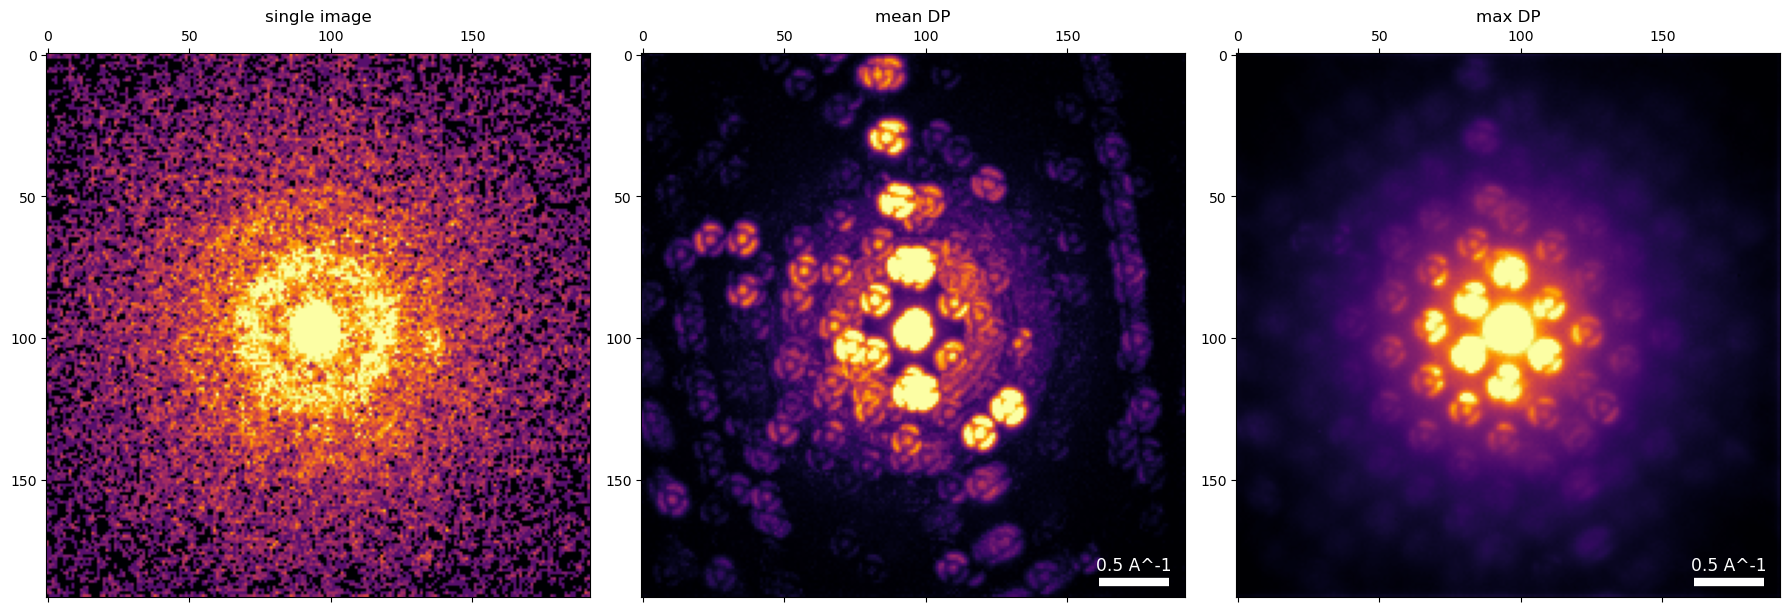

In [15]:
p4.show(
    [datacube.data[40,20],dp_max,dp_mean],
    cmap = 'inferno',
    title = ['single image','mean DP','max DP'],
    power = 0.5,
)
plt.show()

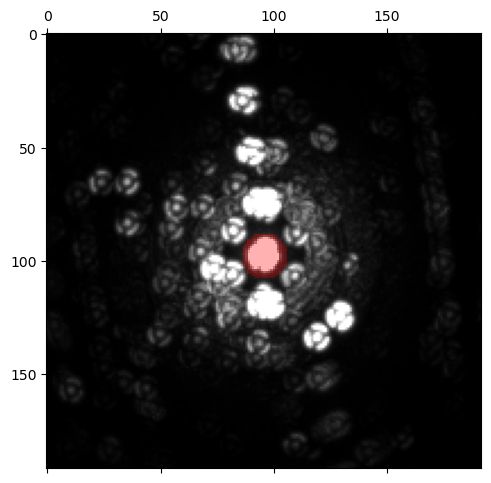

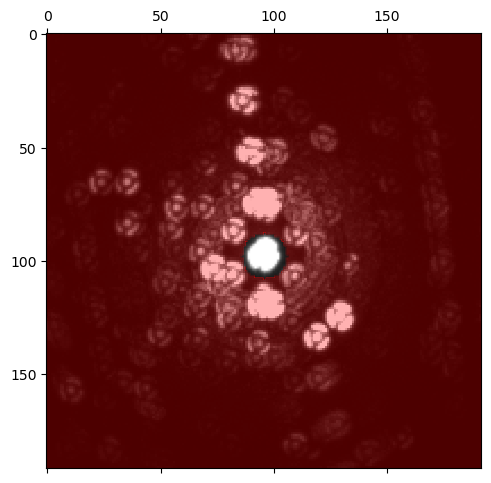

In [18]:
# Virtual imaging - position the detectors

# We'll generate a bright-field (BF) and an annular dark-field (ADF) virtual image
# for both the calibration and measurement datasets

# Set the center
center = (98,96)

# set the geometries
radius_bf = 10
geometry_bf = (center,radius_bf)
geometry_adf = (center,(radius_bf,10e3))

# display the detector positions
datacube.position_detector(
    data = dp_max,
    mode = 'circle',
    geometry = geometry_bf,
)
datacube.position_detector(
    data = dp_max,
    mode = 'annulus',
    geometry = geometry_adf,
)

In [19]:
# Virtual imaging - compute the images

# compute
im_bf = datacube.get_virtual_image(
    mode = 'circle',
    geometry = geometry_bf,
    name = 'bright_field_cal',
)
im_adf = datacube.get_virtual_image(
    mode = 'annulus',
    geometry = geometry_adf,
    name = 'dark_field_cal',
)

# show
p4.show(
    [im_bf,im_adf],
    figsize=(16,2),
    bordercolor = 'w',
    cmap='gray',
    title=['Bright Field (BF)','Annular Dark Field (ADF)'],
    axsize = (2.5,4),
)

100%|██████████| 262144/262144 [00:14<00:00, 18692.31it/s]


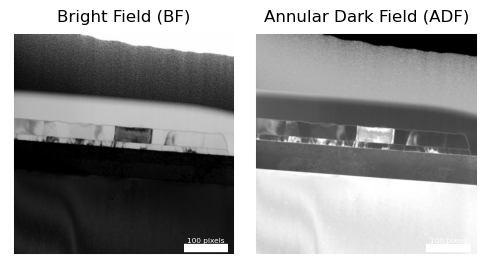

In [20]:
plt.show()

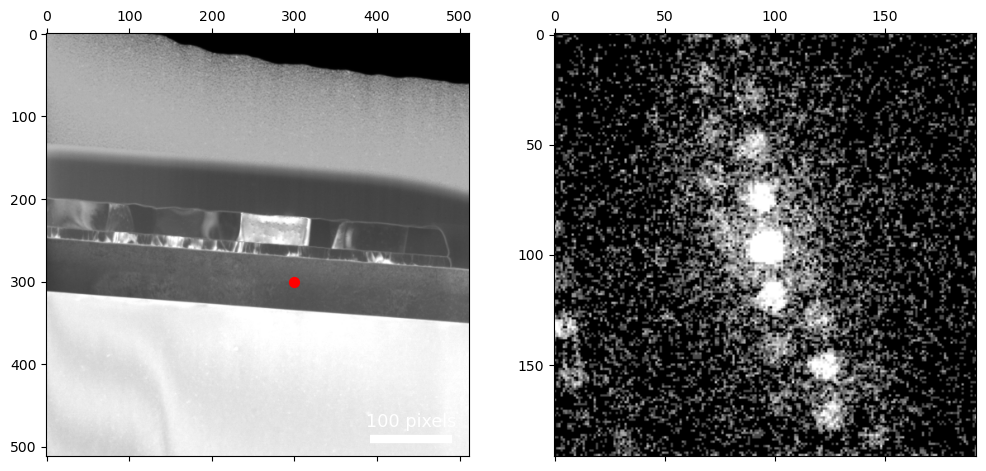

In [23]:
rx,ry = 300,300

p4.visualize.show_selected_dp(
    datacube,
    im_adf,
    rx,
    ry
)

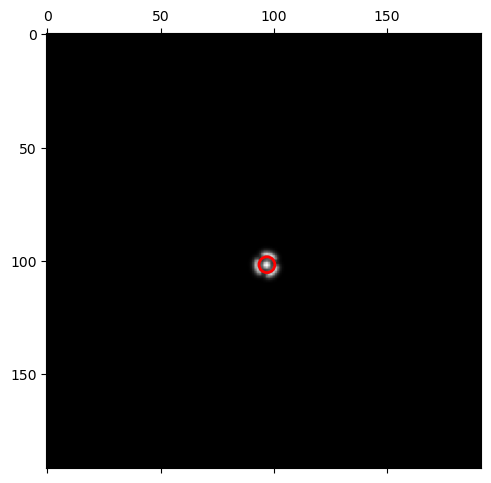

In [24]:
probe_semiangle, probe_qx0, probe_qy0 = p4.process.calibration.get_probe_size(cal_probe.probe)

p4.show(
    cal_probe.probe,
    circle = {
        'center' : (probe_qx0,probe_qy0),
        'R' : probe_semiangle,
    },
    vmax = 1,
)

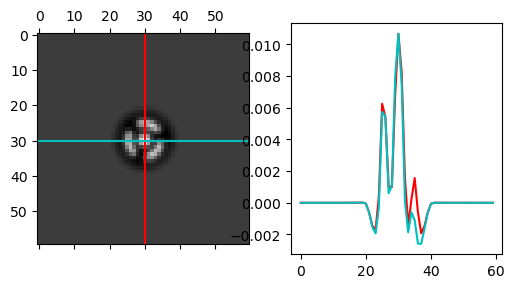

In [25]:
cal_probe.get_kernel(
    mode = 'sigmoid',
    origin = (probe_qx0,probe_qy0),
    radii = (probe_semiangle * 1,
             probe_semiangle * 3,
    )
)

p4.visualize.show_kernel(
    cal_probe.kernel,
    R = 30,
    L = 30,
    W = 1,
    figsize = (6,3),
)

In [29]:
datacube

DataCube( A 4-dimensional array of shape (512, 512, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0,1,2,...] pixels
              Ry = [0,1,2,...] pixels
              Qx = [0.0,0.02,0.04,...] A^-1
              Qy = [0.0,0.02,0.04,...] A^-1
)

In [149]:
##  Select window to save data
d = datacube
name = 'datacube'

ymin, xmin = 0, 190 #bottom left corner of the window to select
ymax, xmax = 512, 512 #size of the window to select
data_partial = d.data[xmin:xmax,
                      ymin:ymax,
                      :,:]
datacube_partial = p4.DataCube(data = data_partial, calibration=d.calibration)


A 'calibration' key already exists in root.metadata - overwriting...


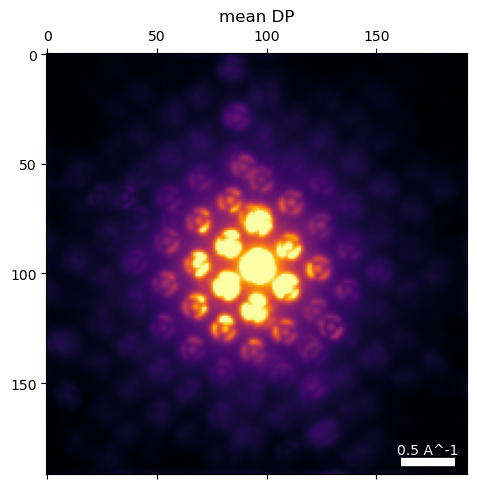

In [150]:
partial_mean = datacube_partial.get_dp_mean()
p4.show(
    partial_mean,
    cmap = 'inferno',
    title = 'mean DP',
    power = 0.5,
)
plt.show()

100%|██████████| 164864/164864 [00:08<00:00, 18884.83it/s]


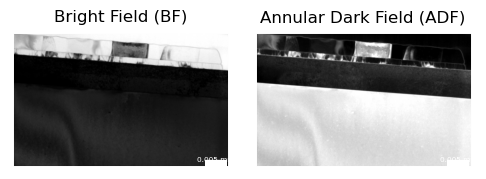

In [155]:
# Virtual imaging - compute the images

# compute
im_bf = datacube_partial.get_virtual_image(
    mode = 'circle',
    geometry = geometry_bf,
    name = 'bright_field_cal',
)
im_adf = datacube_partial.get_virtual_image(
    mode = 'annulus',
    geometry = geometry_adf,
    name = 'dark_field_cal',
)

# show
p4.show(
    [im_bf,im_adf],
    figsize=(16,2),
    bordercolor = 'w',
    cmap='gray',
    title=['Bright Field (BF)','Annular Dark Field (ADF)'],
    axsize = (2.5,4),
)
plt.show()

In [152]:
datacube_partial

DataCube( A 4-dimensional array of shape (322, 512, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0.0,0.0001,0.0002,...] mm
              Ry = [0.0,0.0001,0.0002,...] mm
              Qx = [-96.77850811217722,-96.75850811217722,-96.73850811217721,...] A^-1  (*non-linear*)
              Qy = [-95.85304192586032,-95.83304192586033,-95.81304192586032,...] A^-1  (*non-linear*)
)

In [154]:
datacube_partial.calibration


Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:       0.02
             R_pixel_size:       0.0001
             Q_pixel_units:      A^-1
             R_pixel_units:      mm
             QR_flip:            False
             qx0_meas:           2D-array
             qy0_meas:           2D-array
             origin_meas_mask:   2D-array
             qx0:                2D-array
             qx0_mean:           96.77850811217722
             qx0_shift:          2D-array
             qy0:                2D-array
             qy0_mean:           95.85304192586032
             qy0_shift:          2D-array
)

In [ ]:

p4.save(
    data = datacube_partial,
    filepath = path + f'{name}_partial_loc.h5',
    )


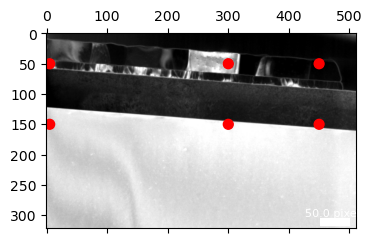

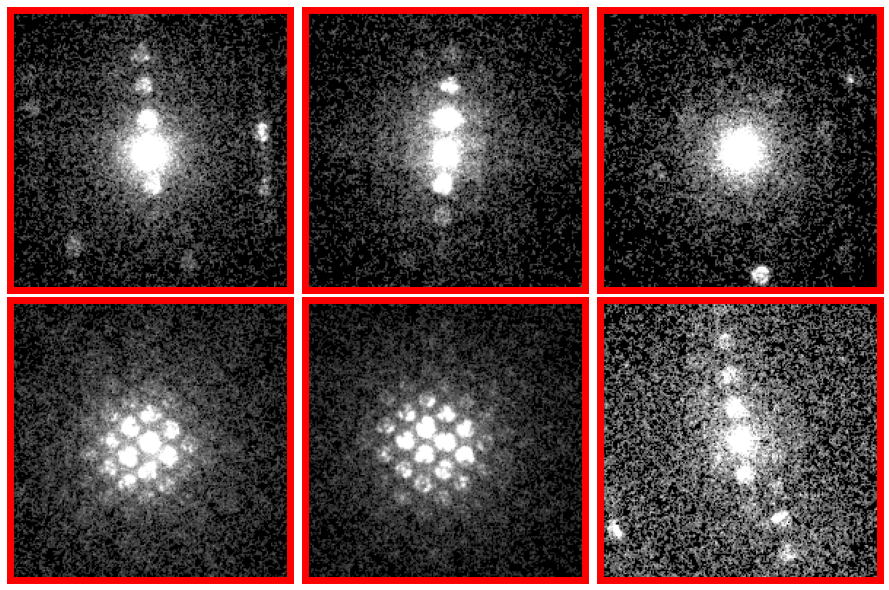

In [40]:
# Choose some diffraction patterns to use for hyperparameter tuning

rxs = 50,50,50,150,150,150
rys = 5,300,450,5,300,450

colors=['r','r','r','r','r','r']


p4.visualize.show_points(
    im_adf,
    x=rxs,
    y=rys,
    pointcolor=colors,
    figsize=(4,4)
)

p4.visualize.show_image_grid(
    get_ar = lambda i:datacube_partial.data[rxs[i],rys[i],:,:],
    H=2,
    W=3,
    axsize=(3,3),
    power = 0.5,
    get_bordercolor = lambda i:colors[i],
)
plt.show()

In [41]:
bg_med = np.median(datacube_partial.data)

def sub_bg(
    im,
    bg_fft=50,
    bg_real = 35,
):
    im_fft = np.fft.fft2(im)
    im_fft = np.maximum(np.abs(im_fft)-bg_fft,0.0) \
        * np.exp(1j * np.angle(im_fft))
    # im_out = np.maximum(np.real(np.fft.ifft2(im_fft)) - bg_real,0.0)
    im_out = np.real(np.fft.ifft2(im_fft)) - bg_real
    return im_out

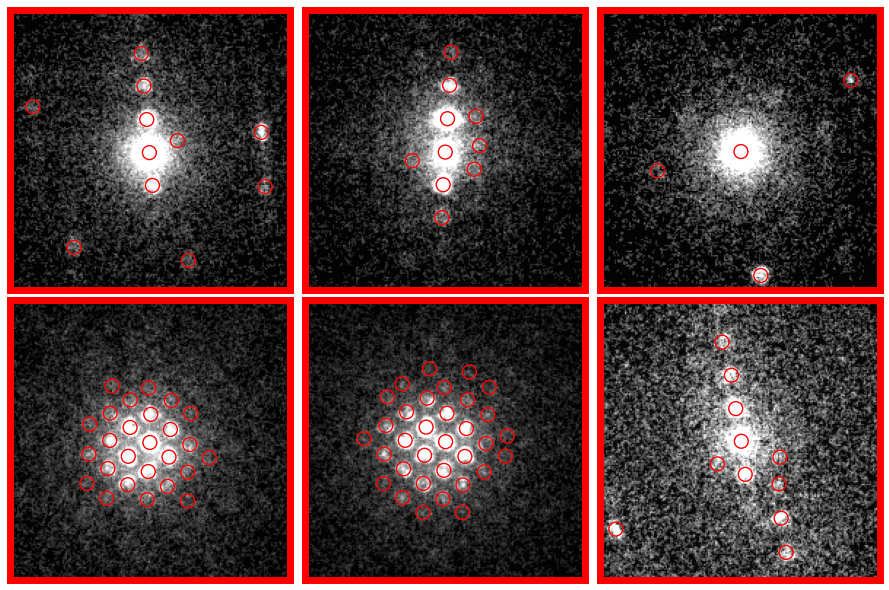

In [47]:
# Tune disk detection parameters

# disk detection parameters
detect_params = {
    'corrPower': 1,
    'sigma': 0,
    'edgeBoundary': 8,
    'minRelativeIntensity': 0.0001,
    'minAbsoluteIntensity': .5,
    'minPeakSpacing': 10,
    'subpixel': 'poly',
    'subpixel' : 'multicorr',
    'upsample_factor': 8,
    'maxNumPeaks': 200,
#     'CUDA': True,
    # 'filter_function': sub_bg,
}
# Note that "poly" subpixel fitting can be used to keep this tutoral fast, but "multicorr"
# is more accurate. For high precision strain mapping, subpixel="multicorr" is recommended.


# find the selected disks
disks_selected = datacube_partial.find_Bragg_disks(
    data = (rxs, rys),
    template = cal_probe.kernel,
    **detect_params,
)

# show
p4.visualize.show_image_grid(
    # get_ar = lambda i:datacube.data[rxs[i],rys[i],:,:],
    get_ar = lambda i:sub_bg(datacube_partial.data[rxs[i],rys[i],:,:]),
    H=2,
    W=3,
    axsize=(3,3),
    power = .5,
    get_bordercolor = lambda i:colors[i],
    get_x = lambda i: disks_selected[i].data['qx'],
    get_y = lambda i: disks_selected[i].data['qy'],
    get_pointcolors = lambda i: colors[i],
    open_circles = True,
    scale = 100,
    # vmin = 0,
    # vmax = 0.,
)
plt.show()

In [48]:
# Find Bragg peaks in all probe positions.

braggpeaks = datacube_partial.find_Bragg_disks(
    template = cal_probe.kernel,
    **detect_params,
)

Finding Bragg Disks: 100%|██████████| 165k/165k [29:48<00:00, 92.2DP/s] 


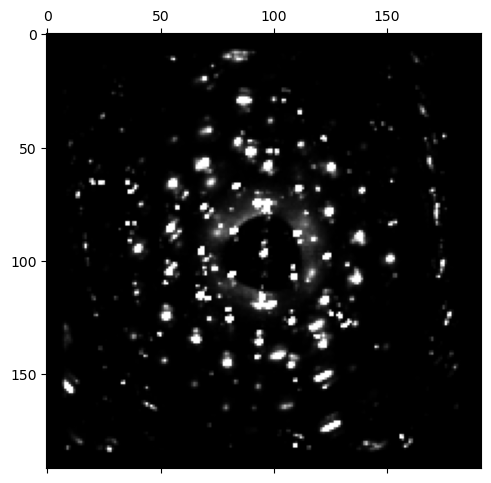

In [49]:
p4.show( braggpeaks.histogram() )

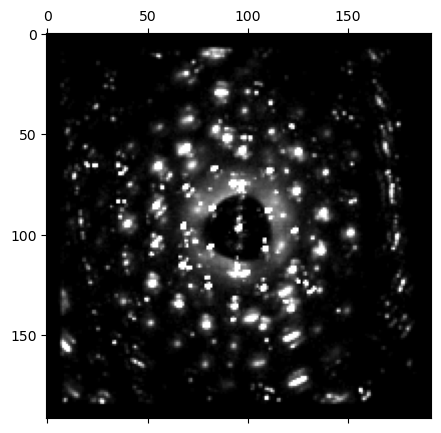

In [52]:
# Compute a Bragg vector map,
# i.e. a 2D histogram of the Bragg peak positions,
# weighted by their correlation intensities

bvm_raw = braggpeaks.histogram(mode = 'raw')

# Plot the BVM
bvm_vis_params = {
    'scaling':'power',
    'power':0.5,
}
p4.show(
    bvm_raw,
    **bvm_vis_params,
    returnfig = True
)
plt.show()

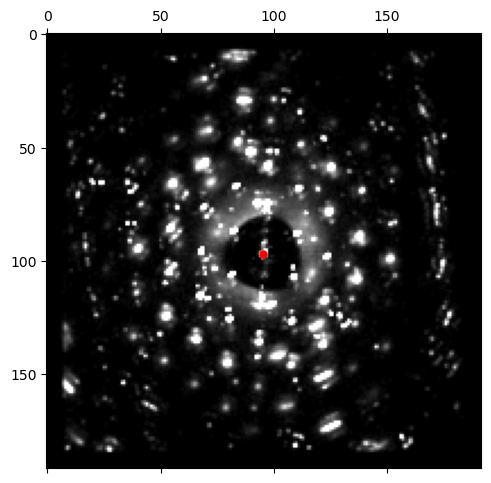

In [56]:
center_guess = 97,95

p4.show(
    bvm_raw,
    points = {'x':center_guess[0],'y':center_guess[1]},
    **bvm_vis_params,
)
plt.show()

In [57]:
# Find the origin at each beam position

# measure the origin
qx0_meas,qy0_meas,mask_meas = braggpeaks.measure_origin( center_guess=center_guess )


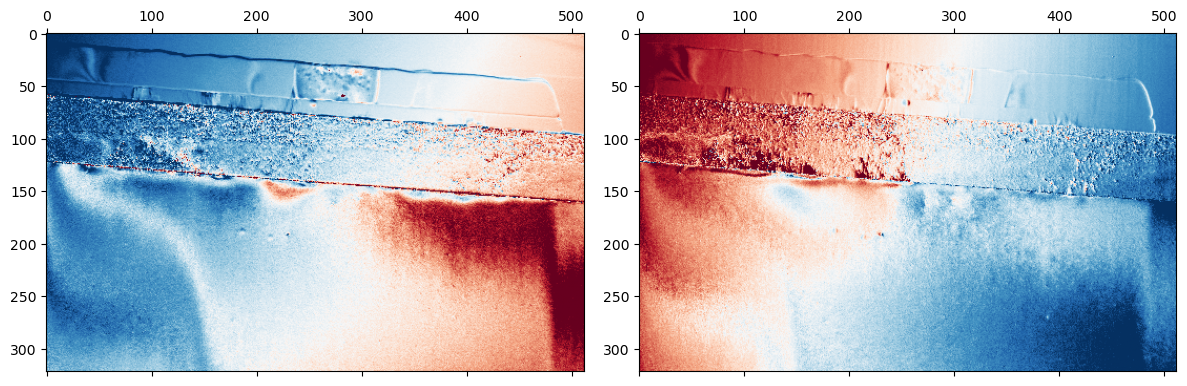

In [60]:
p4.show(
    [qx0_meas,qy0_meas],
    cmap = 'RdBu',
    mask = mask_meas
)
plt.show()

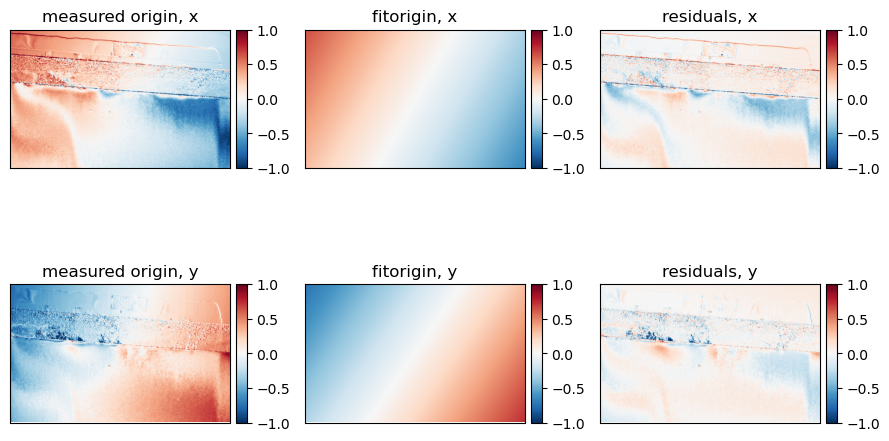

In [63]:

# fit a 2D plane
qx0_fit,qy0_fit,qx0_residuals,qy0_residuals = braggpeaks.fit_origin(
    ticks = False,
    plot_range = 1,
    axsize = (3,4),
)
plt.show()

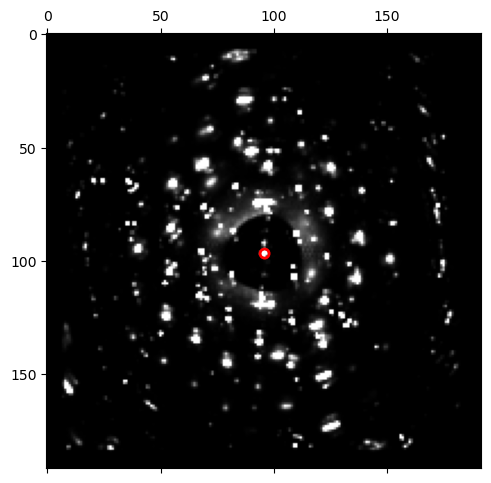

In [65]:
# Get the Bragg vector map after centering using our new origin measurements

# compute
bvm_centered = braggpeaks.histogram()

p4.show(
    bvm_centered,
    circle = {
        'center' : bvm_centered.origin,
        'R' : 2,
    },
    vmin=0,
    vmax=0.98
)
plt.show()

In [70]:
cif_Ta_alpha = "Ta.cif"
cif_Ta_beta = "Ta1.cif"
cif_Al = "Al.cif"
cif_Si = "Si.cif"

In [71]:
crystal_Ta_alpha = p4.process.diffraction.Crystal.from_CIF(cif_Ta_alpha)
crystal_Ta_beta = p4.process.diffraction.Crystal.from_CIF(cif_Ta_beta)
crystal_Al = p4.process.diffraction.Crystal.from_CIF(cif_Al)
crystal_Si = p4.process.diffraction.Crystal.from_CIF(cif_Si)

get_structures is deprecated; use parse_structures in pymatgen.io.cif instead.
The only difference is that primitive defaults to False in the new parse_structures method.So parse_structures(primitive=True) is equivalent to the old behavior of get_structures().


In [ ]:
k_max = 1.4

crystal_Ta_alpha.calculate_structure_factors(k_max=k_max)
crystal_Ta_beta.calculate_structure_factors(k_max=k_max)
crystal_Al.calculate_structure_factors(k_max=k_max)
crystal_Si.calculate_structure_factors(k_max=k_max)

In [73]:
crystal_Ta_alpha.orientation_plan?

Signature:
crystal_Ta_alpha.orientation_plan(
    zone_axis_range: numpy.ndarray = array([[0, 1, 1],
       [1, 1, 1]]),
    angle_step_zone_axis: float = 2.0,
    angle_coarse_zone_axis: float = None,
    angle_refine_range: float = None,
    angle_step_in_plane: float = 2.0,
    accel_voltage: float = 300000.0,
    corr_kernel_size: float = 0.08,
    sigma_excitation_error: float = 0.02,
    precession_angle_degrees=None,
    power_radial: float = 1.0,
    power_intensity: float = 0.25,
    power_intensity_experiment: float = 0.25,
    calculate_correlation_array=True,
    tol_peak_delete=None,
    tol_distance: float = 0.01,
    fiber_axis=None,
    fiber_angles=None,
    figsize: Union[list, tuple, numpy.ndarray] = (6, 6),
    CUDA: bool = False,
    progress_bar: bool = True,
)
Docstring:
Calculate the rotation basis arrays for an SO(3) rotation correlogram.

Parameters
----------
zone_axis_range (float):
    Row vectors give the range for zone axis orientations.
    If user speci

In [74]:
# Make orientation plans
# Note that we're doing a coarse search over 4 degree step sizes and only refining to 2 degrees.
# This is done to make the tutorial take much less time.

acom_params = {
    'zone_axis_range': 'auto',

    'angle_step_zone_axis': 2.5,
    'angle_coarse_zone_axis': 5.0,
    'angle_refine_range': 3.0,
    'angle_step_in_plane': 10.0,

    'accel_voltage': 300e3,
    'corr_kernel_size': 0.04,

    'power_intensity': 0.5,
    'power_intensity_experiment': 0.5,

    'sigma_excitation_error': 0.02,
    'precession_angle_degrees': 0.5,
}

crystal_Ta_alpha.orientation_plan(**acom_params)
crystal_Ta_beta.orientation_plan(**acom_params)
crystal_Al.orientation_plan(**acom_params)
crystal_Si.orientation_plan(**acom_params)

Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 276/276 [00:00<00:00, 4757.60 zone axes/s]


Automatically detected point group 4/mmm,
 using arguments: zone_axis_range = 
[[1 0 0]
 [1 1 0]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 703/703 [00:00<00:00, 2067.18 zone axes/s]


Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 276/276 [00:00<00:00, 5017.02 zone axes/s]


Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 276/276 [00:00<00:00, 4757.60 zone axes/s]


In [ ]:
# Crop the datacube to a smaller region for faster processing
crop_params = {
    'R_Nx': 256,
    'R_Ny': 256,
    'R_x0': 128,
    'R_y0': 128
}

datacube_cropped = datacube_partial.data[crop_params['R_y0']:crop_params['R_y0']+crop_params['R_Ny'],
                                         crop_params['R_x0']:crop_params['R_x0']+crop_params['R_Nx'],:,:]

# Create virtual image overlay
fig, ax = plt.subplots(figsize=(8, 8))

# Show the virtual ADF image as background
p4.show(
    
)


TypeError: Image data of dtype object cannot be converted to float

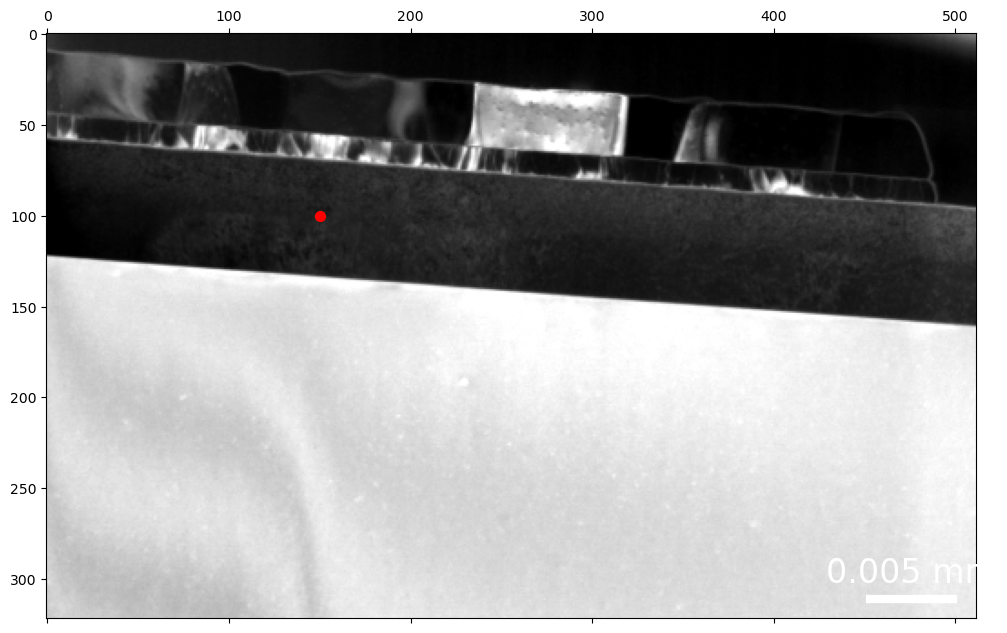

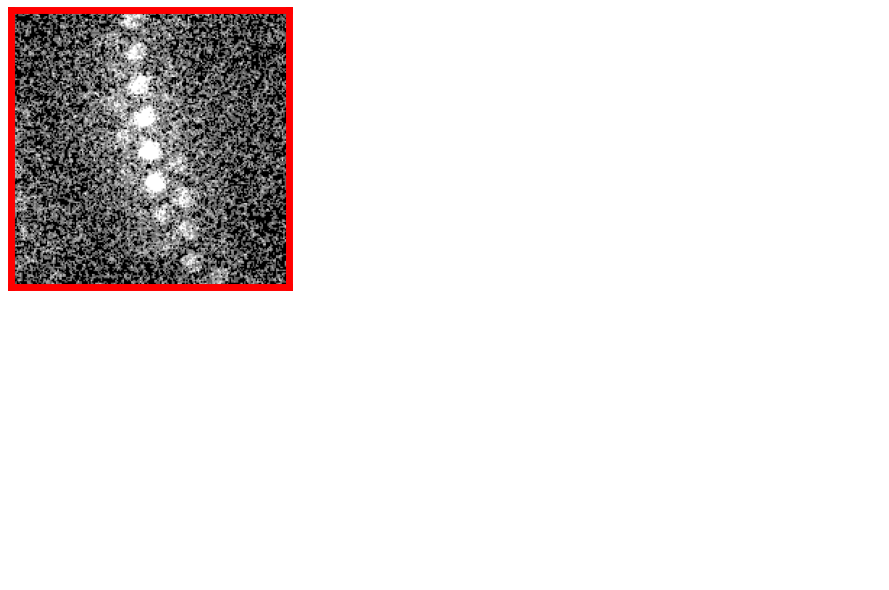

In [158]:
# Choose some diffraction patterns to use for hyperparameter tuning

rxs = 100,
rys = 150,

colors=['r']


p4.visualize.show_points(
    im_adf,
    x=rxs,
    y=rys,
    pointcolor=colors,
    figsize=(12,12)
)

p4.visualize.show_image_grid(
    get_ar = lambda i:datacube_partial.data[rxs[i],rys[i],:,:],
    H=2,
    W=3,
    axsize=(3,3),
    power = 0.5,
    get_bordercolor = lambda i:colors[i],
)
plt.show()

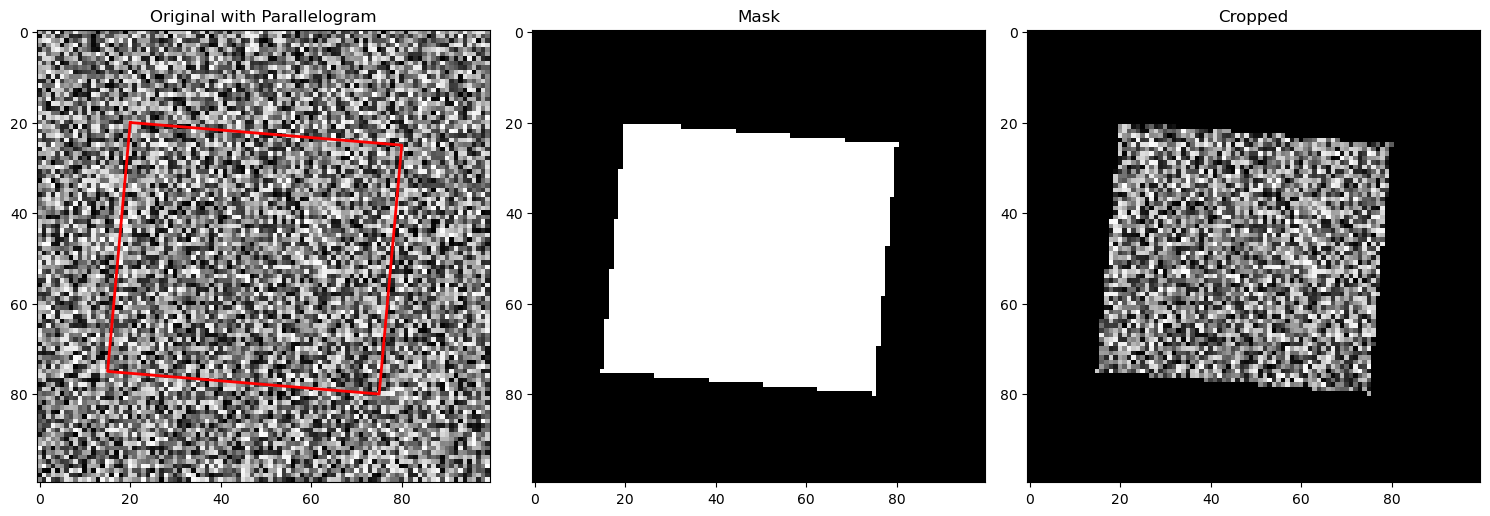

In [101]:
import numpy as np
from matplotlib.path import Path
import matplotlib.pyplot as plt

def crop_parallelogram(arr, corners):
    """
    Crop a 2D array along a parallelogram defined by four corners.

    Parameters:
        arr: 2D numpy array
        corners: list of four (x, y) tuples, in order (e.g., top-left, top-right, bottom-right, bottom-left)

    Returns:
        cropped: 2D numpy array, with values outside the parallelogram set to 0 (or np.nan)
        mask: boolean mask of the parallelogram region
    """
    h, w = arr.shape
    y, x = np.mgrid[0:h, 0:w]
    points = np.vstack((x.ravel(), y.ravel())).T
    poly_path = Path(corners)
    mask = poly_path.contains_points(points).reshape(h, w)
    cropped = np.where(mask, arr, 0)
    return cropped, mask

def visualize_crop(arr, corners, cropped, mask):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    # Original with parallelogram
    axs[0].imshow(arr, cmap='gray')
    corners_closed = np.array(corners + [corners[0]])
    axs[0].plot(corners_closed[:,0], corners_closed[:,1], 'r-', lw=2)
    axs[0].set_title('Original with Parallelogram')
    # Mask
    axs[1].imshow(mask, cmap='gray')
    axs[1].set_title('Mask')
    # Cropped
    axs[2].imshow(cropped, cmap='gray')
    axs[2].set_title('Cropped')
    plt.tight_layout()
    plt.show()

# Example usage:
arr = np.random.rand(100, 100)
corners = [(20, 20), (80, 25), (75, 80), (15, 75)]
cropped, mask = crop_parallelogram(arr, corners)
visualize_crop(arr, corners, cropped, mask)

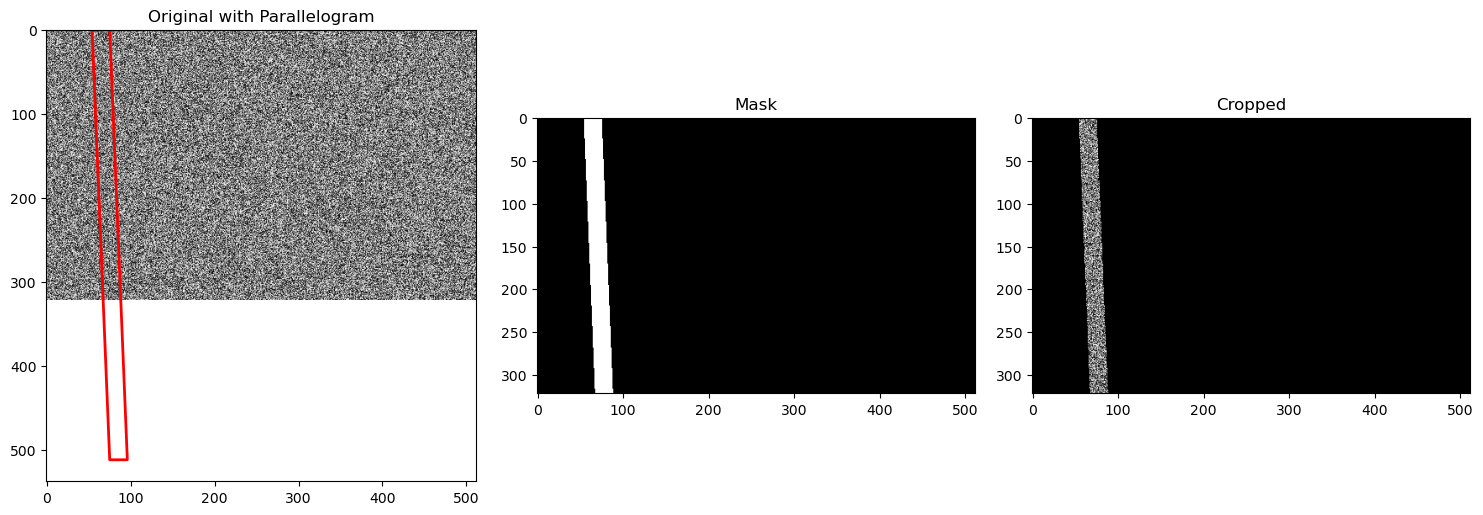

In [120]:
corners = [(54,0),(75,512),(75+21,512),(54+21,0)]



# Example usage:
arr = np.random.rand(322, 512)
cropped, mask = crop_parallelogram(arr, corners)
visualize_crop(arr, corners, cropped, mask)


In [121]:
np.shape(mask)

(322, 512)

In [122]:
np.shape(datacube_partial)

(322, 512, 192, 192)

In [137]:
datacube_partial

DataCube( A 4-dimensional array of shape (322, 512, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0,1,2,...] pixels
              Ry = [0,1,2,...] pixels
              Qx = [-96.77850811217722,-96.75850811217722,-96.73850811217721,...] A^-1  (*non-linear*)
              Qy = [-95.85304192586032,-95.83304192586033,-95.81304192586032,...] A^-1  (*non-linear*)
)

In [141]:
np.shape(mask)

(322, 512)

In [139]:
np.shape(sliced_data)

(6741, 192, 192)

In [142]:
##  Select window to save data
# d = datacube
# name = 'datacube'

# ymin, xmin = 0, 190 #bottom left corner of the window to select
# ymax, xmax = 512, 512 #size of the window to select
# data_partial = d.data[xmin:xmax,
#                       ymin:ymax,
#                       :,:]
# datacube_partial = p4.DataCube(data = data_partial, calibration=d.calibration)
sliced_data = datacube_partial[mask, :, :]

Best fit lattice directions: z axis = ([0.141 0.673 0.726]), x axis = ([0.134 0.688 0.714]), with corr value = 1.698
Best fit lattice directions: z axis = ([0.122 0.158 0.98 ]), x axis = ([0.051 0.612 0.789]), with corr value = 1.37
Best fit lattice directions: z axis = ([0.739 0.022 0.673]), x axis = ([0.85  0.149 0.505]), with corr value = 1.318
Best fit lattice directions: z axis = ([0.924 0.383 0.   ]), x axis = ([0.335 0.139 0.932]), with corr value = 0.756


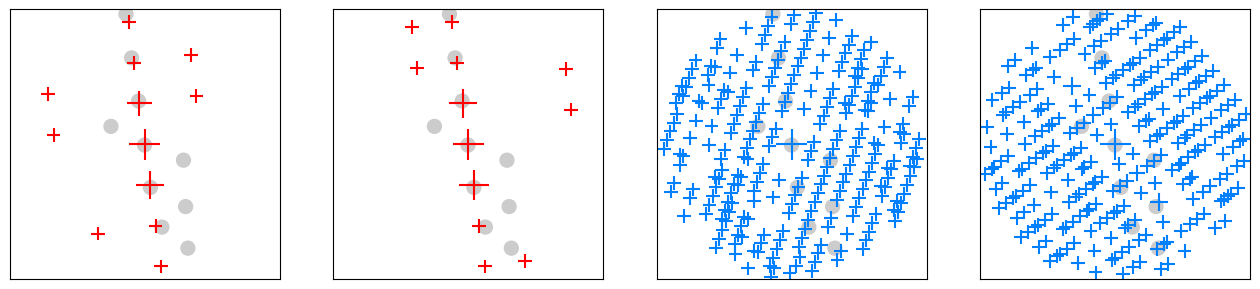

In [91]:
# Test orientation_matching on some probe positions


xind, yind = 100,150

min_angle_between_matches_deg = 30
precession_angle_degrees = 0.5
sigma_compare = 0.02
num_matches_return = 2


# Fit all crystals
orientation_Ta_alpha  = crystal_Ta_alpha.match_single_pattern(
    braggpeaks.cal[xind,yind],
    num_matches_return = num_matches_return,
    verbose = True,
    min_angle_between_matches_deg=min_angle_between_matches_deg,
)
orientation_Ta_beta  = crystal_Ta_beta.match_single_pattern(
    braggpeaks.cal[xind,yind],
    num_matches_return = num_matches_return,
    verbose = True,
    min_angle_between_matches_deg=min_angle_between_matches_deg,
)


# Generate test diffraction patterns for matches 0 and 1
bragg_peaks_fit_Ta_alpha_0 = crystal_Ta_alpha.generate_diffraction_pattern(
    orientation_Ta_alpha,
    ind_orientation=0,
    sigma_excitation_error=sigma_compare,
    precession_angle_degrees = precession_angle_degrees,
)
bragg_peaks_fit_Ta_alpha_1 = crystal_Ta_alpha.generate_diffraction_pattern(
    orientation_Ta_alpha,
    ind_orientation=1,
    sigma_excitation_error=sigma_compare,
    precession_angle_degrees = precession_angle_degrees,
)

bragg_peaks_fit_Ta_beta_0 = crystal_Ta_beta.generate_diffraction_pattern(
    orientation_Ta_beta,
    ind_orientation=0,
    sigma_excitation_error=sigma_compare,
    precession_angle_degrees = precession_angle_degrees,
)
bragg_peaks_fit_Ta_beta_1 = crystal_Ta_beta.generate_diffraction_pattern(
    orientation_Ta_beta,
    ind_orientation=1,
    sigma_excitation_error=sigma_compare,
    precession_angle_degrees = precession_angle_degrees,
)


# plotting frame
figsize = (4,4)
fig,ax = plt.subplots(1,4,figsize=(4*figsize[0],1*figsize[1]))

plot_params = {
    'bragg_peaks_compare':     braggpeaks.cal[xind,yind],
    # 'plot_range_kx_ky':  np.array([k_max,k_max]),
    'plot_range_kx_ky':  np.array([1.4,1.4]),
    'min_marker_size': 100,
    'max_marker_size': 500,
    'add_labels': False,

    'scale_markers': 4000,
    'scale_markers_compare': 0.02,
    'marker': '+',
    'facecolor_compare': (0.8,0.8,0.8),

    # 'color':(1,0,0),
    'edgecolor': None,
    # 'facecolor': 'none',
    'linewidth':1.5,
    'show_axes':False
}


# plot comparisons
# Ti alpha
p4.process.diffraction.plot_diffraction_pattern(
    bragg_peaks = bragg_peaks_fit_Ta_alpha_0,
    input_fig_handle=(fig,[ax[0]]),
    color = (1.0,0.0,0.0),
    **plot_params,
)
p4.process.diffraction.plot_diffraction_pattern(
    bragg_peaks = bragg_peaks_fit_Ta_alpha_1,
    input_fig_handle=(fig,[ax[1]]),
    color = (1.0,0.0,0.0),
    **plot_params,
)
# Ti beta
p4.process.diffraction.plot_diffraction_pattern(
    bragg_peaks = bragg_peaks_fit_Ta_beta_0,
    input_fig_handle=(fig,[ax[2]]),
    color = (0.0,0.5,1.0),
    **plot_params,
)
p4.process.diffraction.plot_diffraction_pattern(
    bragg_peaks = bragg_peaks_fit_Ta_beta_1,
    input_fig_handle=(fig,[ax[3]]),
    color = (0.0,0.5,1.0),
    **plot_params,
)
plt.show()

In [94]:
crystal_Ta_alpha.match_orientations?

Signature:
crystal_Ta_alpha.match_orientations(
    bragg_peaks_array: emdfile.classes.pointlistarray.PointListArray,
    num_matches_return: int = 1,
    min_angle_between_matches_deg=None,
    min_number_peaks: int = 3,
    inversion_symmetry: bool = True,
    multiple_corr_reset: bool = True,
    return_orientation: bool = True,
    progress_bar: bool = True,
)
Docstring:
Parameters
--------
bragg_peaks_array: PointListArray
    PointListArray containing the Bragg peaks and intensities, with calibrations applied
num_matches_return: int
    return these many matches as 3th dim of orient (matrix)
min_angle_between_matches_deg: int
    Minimum angle between zone axis of multiple matches, in degrees.
    Note that I haven't thought how to handle in-plane rotations, since multiple matches are possible.
min_number_peaks: int
    Minimum number of peaks required to perform ACOM matching
inversion_symmetry: bool
    check for inversion symmetry in the matches
multiple_corr_reset: bool
    k

In [ ]:
# Fit orientation to all probe positions
num_matches_return = 1
min_angle_between_matches_deg = 30

orientation_map_Ta_alpha = crystal_Ta_alpha.match_orientations(
    braggpeaks,
    num_matches_return = num_matches_return,
    min_angle_between_matches_deg = min_angle_between_matches_deg,
)



bragg peaks not rotationally calibrated
Matching Orientations: 100%|██████████| 164864/164864 [05:43<00:00, 480.34 PointList/s]
bragg peaks not rotationally calibrated
Matching Orientations:   7%|▋         | 10855/164864 [06:08<1:27:05, 29.47 PointList/s]


KeyboardInterrupt: 

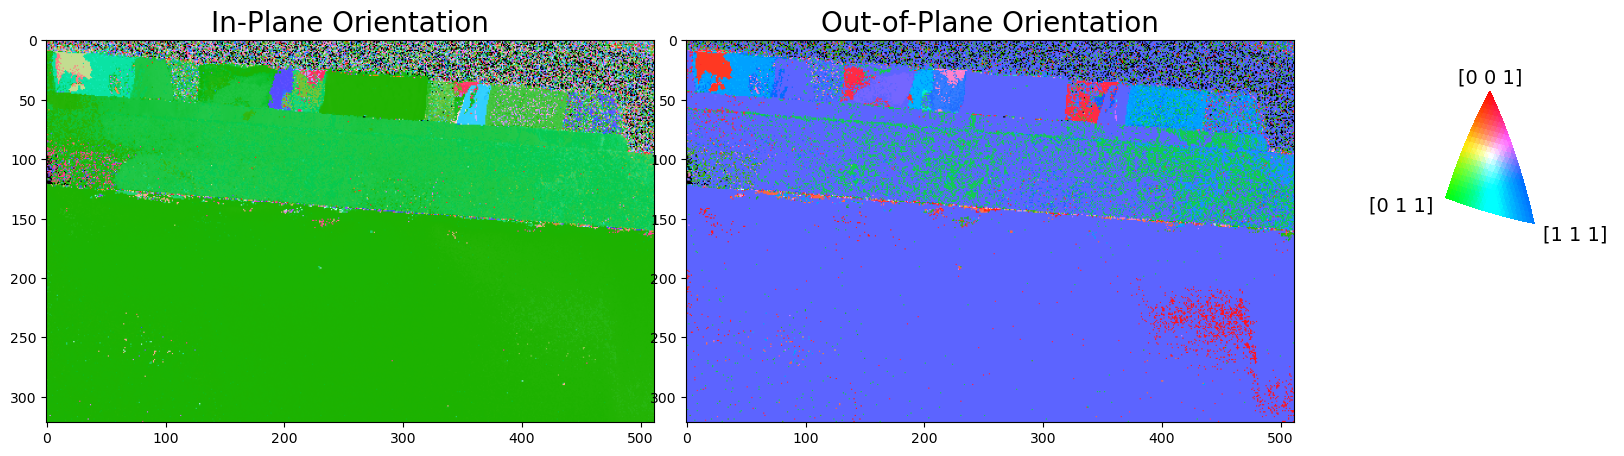

In [157]:
c_r = (0,0.01)

im_alpha = crystal_Ta_alpha.plot_orientation_maps(
    orientation_map = crystal_Ta_alpha.orientation_map,
    corr_range = c_r,
    figsize = (16,8),
    show_legend = True,
    # camera_dist = 10,
)
plt.show()

In [144]:
orientation_map_Si = crystal_Si.match_orientations(
    braggpeaks,
    num_matches_return = num_matches_return,
    min_angle_between_matches_deg = min_angle_between_matches_deg,
)

orientation_map_Al = crystal_Al.match_orientations(
    braggpeaks,
    num_matches_return = num_matches_return,
    min_angle_between_matches_deg = min_angle_between_matches_deg,
)

bragg peaks not rotationally calibrated
Matching Orientations: 100%|██████████| 164864/164864 [06:22<00:00, 430.64 PointList/s]
bragg peaks not rotationally calibrated
Matching Orientations: 100%|██████████| 164864/164864 [05:43<00:00, 479.75 PointList/s]


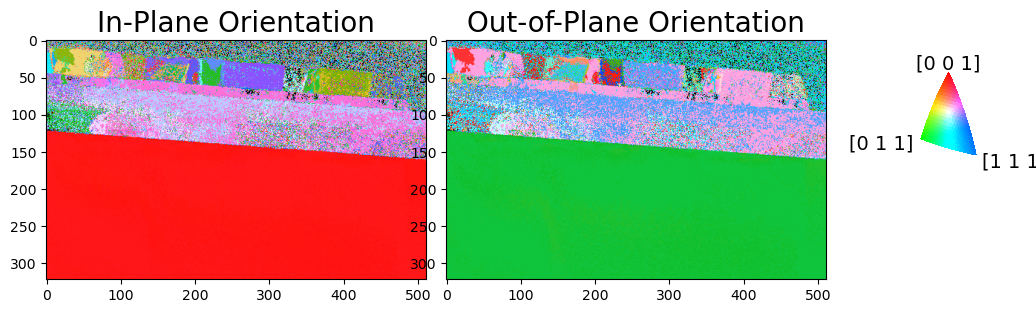

In [161]:
c_r = (0,0.01)

im_alpha = crystal_Si.plot_orientation_maps(
    orientation_map = crystal_Si.orientation_map,
    corr_range = c_r,
    figsize = (10,4),
    show_legend = True,
    # camera_dist = 10,
    
)
plt.savefig('orientation_map_Si.png')

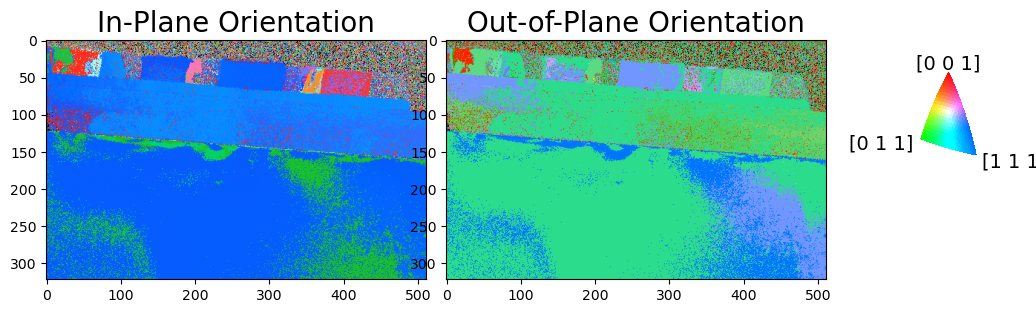

In [146]:
c_r = (0,0.01)

im_alpha = crystal_Al.plot_orientation_maps(
    orientation_map = crystal_Al.orientation_map,
    corr_range = c_r,
    figsize = (10,4),
    show_legend = True,
    # camera_dist = 10,
)
plt.show()